# **Part 1: Foundation Model Exploration**

## 1A. Setup and Inference

In [ ]:
pip install transformers

In [ ]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
import pandas as pd

# dataset from HW2 with non-empty review comment message
df = pd.read_csv("df.csv")
df = df.drop(columns=['review_score'])
df.head()

,customer_zip_code_prefix,customer_city,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,seller_zip_code_prefix,seller_city,...,delivery_days,delivery_vs_estimated,is_repeat_customer,seller_state_match,product_volume,is_positive_review,total_order_items,log_price,seller_orders_count,is_delivered
0,3149,sao paulo,8.72,40.0,268.0,4.0,500.0,housewares,9350.0,maua,...,8.0,-8.0,0,1,1976.0,1,1.0,3.433665,53.0,1
1,47813,barreiras,22.76,29.0,178.0,1.0,400.0,perfumery,31570.0,belo horizonte,...,13.0,-6.0,0,0,4693.0,1,1.0,4.784989,110.0,1
2,59296,sao goncalo do amarante,27.20,59.0,468.0,3.0,450.0,pet_shop,31842.0,belo horizonte,...,13.0,-13.0,0,0,6000.0,1,1.0,3.828641,151.0,1
3,98900,santa rosa,16.05,52.0,595.0,1.0,600.0,unknown,5455.0,sao paulo,...,-1.0,0.0,0,0,18375.0,0,1.0,3.929863,41.0,0
4,20780,rio de janeiro,30.53,36.0,450.0,1.0,9000.0,garden_tools,29156.0,cariacica,...,12.0,-9.0,1,0,19656.0,0,2.0,4.605170,200.0,1


In [ ]:
df_sample = df.sample(n=500, random_state=42)
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 6113 to 41113
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_zip_code_prefix       500 non-null    int64  
 1   customer_city                  500 non-null    object 
 2   freight_value                  500 non-null    float64
 3   product_name_lenght            500 non-null    float64
 4   product_description_lenght     500 non-null    float64
 5   product_photos_qty             500 non-null    float64
 6   product_weight_g               500 non-null    float64
 7   product_category_name_english  500 non-null    object 
 8   seller_zip_code_prefix         500 non-null    float64
 9   seller_city                    500 non-null    object 
 10  seller_state                   500 non-null    object 
 11  review_comment_message         500 non-null    object 
 12  payment_type                   500 non-null    obj

### Sentiment - analysis

In [ ]:
sentiment_results = sentiment(df_sample['review_comment_message'].tolist())

sentiment_labels = [res['label'] for res in sentiment_results]
sentiment_scores = [res['score'] for res in sentiment_results]

df_sample['sentiment_label'] = sentiment_labels
df_sample['sentiment_score'] = sentiment_scores

In [ ]:
def map_sentiment_to_binary(label):
    if label in ['5 stars', '4 stars']:
        return 1
    elif label in ['3 stars', '2 stars', '1 star']:
        return 0
    return None

df_sample['is_positive_review_sentiment'] = df_sample['sentiment_label'].apply(map_sentiment_to_binary)
df_sample.head()

,customer_zip_code_prefix,customer_city,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,seller_zip_code_prefix,seller_city,...,seller_state_match,product_volume,is_positive_review,total_order_items,log_price,seller_orders_count,is_delivered,sentiment_label,sentiment_score,is_positive_review_sentiment
6113,12916,braganca paulista,11.42,42.0,534.0,1.0,983.0,health_beauty,5588.0,sao paulo,...,1,33005.0,1,1.0,4.072440,85.0,1,4 stars,0.491518,1
19038,76420,niquelandia,15.93,56.0,1224.0,3.0,556.0,perfumery,14085.0,riberao preto,...,0,5376.0,1,1.0,5.129425,255.0,0,4 stars,0.576948,1
37607,22793,rio de janeiro,15.37,39.0,772.0,1.0,150.0,sports_leisure,3933.0,sao paulo,...,0,2816.0,1,1.0,3.688879,261.0,1,5 stars,0.684228,1
16145,11680,ubatuba,11.85,52.0,595.0,1.0,300.0,unknown,17512.0,marilia,...,1,3780.0,1,1.0,3.433987,17.0,1,4 stars,0.467121,1
6904,75690,caldas novas,15.10,47.0,187.0,2.0,100.0,fashion_underwear_beach,5126.0,sao paulo,...,0,2340.0,1,1.0,1.589235,62.0,1,5 stars,0.666976,1


In [ ]:
print("Actual Class Distribution:")
print(df_sample['is_positive_review'].value_counts())
print("\nPredicted Class Distribution:")
print(df_sample['is_positive_review_sentiment'].value_counts())

Actual Class Distribution:
is_positive_review
1    312
0    188
Name: count, dtype: int64

Predicted Class Distribution:
is_positive_review_sentiment
1    252
0    248
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = df_sample['is_positive_review']
y_pred = df_sample['is_positive_review_sentiment']

y_pred_filtered = y_pred.dropna()
y_true_filtered = y_true[y_pred.notna()]

accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
precision = precision_score(y_true_filtered, y_pred_filtered)
recall = recall_score(y_true_filtered, y_pred_filtered)
f1 = f1_score(y_true_filtered, y_pred_filtered)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8200
Precision: 0.9405
Recall: 0.7596
F1 Score: 0.8404


### HW model on the same sample size

In [ ]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 6113 to 41113
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_zip_code_prefix       500 non-null    int64  
 1   customer_city                  500 non-null    object 
 2   freight_value                  500 non-null    float64
 3   product_name_lenght            500 non-null    float64
 4   product_description_lenght     500 non-null    float64
 5   product_photos_qty             500 non-null    float64
 6   product_weight_g               500 non-null    float64
 7   product_category_name_english  500 non-null    object 
 8   seller_zip_code_prefix         500 non-null    float64
 9   seller_city                    500 non-null    object 
 10  seller_state                   500 non-null    object 
 11  review_comment_message         500 non-null    object 
 12  payment_type                   500 non-null    obj

In [ ]:
# Train/test split — stratified to preserve class balance using shared indices
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

X = df_sample.drop(columns=['is_positive_review', 'review_comment_message'])
y = df_sample['is_positive_review']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train balance: {y_train.mean():.1%} positive | Test balance: {y_test.mean():.1%} positive")


Train: 400, Test: 100
Train balance: 62.5% positive | Test balance: 62.0% positive


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['string', 'category', 'object']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', cat_pipeline_tree, cat_cols)
])

In [ ]:
# Tuned Random Forest

pipe_tuned = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(pipe_tuned, param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best RF params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

Best RF params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best CV ROC-AUC: 0.749


In [ ]:
# Tuned RF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
best_rf = grid.best_estimator_

y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]
y_pred_tuned = best_rf.predict(X_test)

print(f"{'Metric':<12}")
print("-" * 34)
print(f"{'Accuracy':<12} {accuracy_score(y_test, y_pred_tuned):>10.3f}")
print(f"{'F1':<12} {f1_score(y_test, y_pred_tuned):>10.3f}")
print(f"{'Recall':<12} {recall_score(y_test, y_pred_tuned):>10.3f}")
print(f"{'Precision':<12} {precision_score(y_test, y_pred_tuned):>10.3f}")

Metric      
----------------------------------
Accuracy          0.650
F1                0.752
Recall            0.855
Precision         0.671


## 1B. Performance Comparison (5 points)

## Comparison Table

| Metric| Foundation Model (review text) | HW2 Manual (order features) |
|---------|---------|---------|
| Accuracy | 0.82 | 0.65 |
| Precision | 0.94 | 0.67|
| Recall | 0.76 | 0.86 |
| F1 Score | 0.84 | 0.75 |

## 1C. Reflection

1. **Best model:** BERT achieved 0.82 accuracy and 0.84 F1, while my tuned Random Forest only got 0.65 accuracy and 0.75 F1.
BERT is reading what the customer wrote, so it better understands the sentiment. While HW2 Random Forest was trying to guess satisfaction from things like package weight and freight value. The one area where Random Forest did better was recall (0.86 vs 0.76), meaning it was better at catching all the positive reviews, but it also made a lot more false positives to do that.

2. **Advantage vs Disadvantage:** I didn't have to label any data or spend time training. It also handles Portuguese naturally since it's a multilingual model. The downside is that running BERT on 500 records took longer than the Random Forest, so scaling it to production would require more compute resources.

3. **When to use:** I would use a foundation model when I'm just starting out and don't have much labeled data yet, or when the main signal is text. If I had a huge labeled dataset and needed fast predictions on structured data, I'd go with a custom model.

4. **Combination:** I could run BERT on the review text and use its confidence score as an extra feature in my Random Forest alongside the order data. That way the structured model gets an emotional value from the text.

# **Part 2: Experiment Tracking with MLflow**

## 2A. Logging Experiments

In [ ]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("mlruns")
experiment_name = "olist-satisfaction"
mlflow.set_experiment(experiment_name)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {experiment_name}")

MLflow tracking URI: mlruns
Experiment: olist-satisfaction


In [ ]:
from sklearn.metrics import roc_auc_score

# Define models to compare
models = {
    "random-forest-tuned": {
        "model": best_rf,
        "params": {
            "model_type": "RandomForest_Tuned",
            "n_estimators": grid.best_params_['classifier__n_estimators'],
            "max_depth": grid.best_params_['classifier__max_depth'],
            "min_samples_split": grid.best_params_['classifier__min_samples_split']
        }
    },
    "random-forest-untuned": {
        "model": Pipeline([
            ('preprocessor', preprocessor_tree), # Using the same preprocessor as tuned RF
            ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # Default parameters
        ]),
        "params": {
            "model_type": "RandomForest_Untuned",
            "n_estimators": 100, # Default value
            "max_depth": None,   # Default value
            "min_samples_split": 2 # Default value
        }
    }
}

run_ids = {}  # store for later use

for run_name, config in models.items():
    with mlflow.start_run(run_name=run_name) as run:
        pipeline = config["model"]

        # Log parameters
        for param_name, param_value in config["params"].items():
            mlflow.log_param(param_name, param_value)
        mlflow.log_param("n_features_numeric", len(numeric_cols))
        mlflow.log_param("n_features_categorical", len(cat_cols))
        mlflow.log_param("train_size", len(X_train))

        # For the untuned model, we need to fit it
        if run_name == "random-forest-untuned":
            pipeline.fit(X_train, y_train)

        # Evaluate
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)

        # Log metrics
        mlflow.log_metric("auc", round(auc, 4))
        mlflow.log_metric("f1", round(f1, 4))
        mlflow.log_metric("accuracy", round(acc, 4))
        mlflow.log_metric("precision", round(prec, 4))
        mlflow.log_metric("recall", round(rec, 4))

        # Log the model
        mlflow.sklearn.log_model(pipeline, "model")

        # Save run ID
        run_ids[run_name] = run.info.run_id

        print(f"\n{'='*60}")
        print(f"Run: {run_name}")
        print(f"  AUC:      {auc:.4f}")
        print(f"  F1:       {f1:.4f}")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:   {rec:.4f}")
        print(f"  Run ID:   {run.info.run_id}")

print(f"\n{'='*60}")
print(f"All models logged to MLflow experiment: '{experiment_name}'")
print(f"Run IDs saved for later demos")

2026/04/19 16:56:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 16:56:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/19 16:56:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 16:56:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p


Run: random-forest-tuned
  AUC:      0.6486
  F1:       0.7518
  Accuracy: 0.6500
  Precision: 0.6709
  Recall:   0.8548
  Run ID:   b6aa778950a745fa8deed1b7b980f6f6

Run: random-forest-untuned
  AUC:      0.6473
  F1:       0.7445
  Accuracy: 0.6500
  Precision: 0.6800
  Recall:   0.8226
  Run ID:   ff30a05a11a04b58bc429f9b7f8a17aa

All models logged to MLflow experiment: 'olist-satisfaction'
Run IDs saved for later demos


## 2B. Model Registry and Screenshots

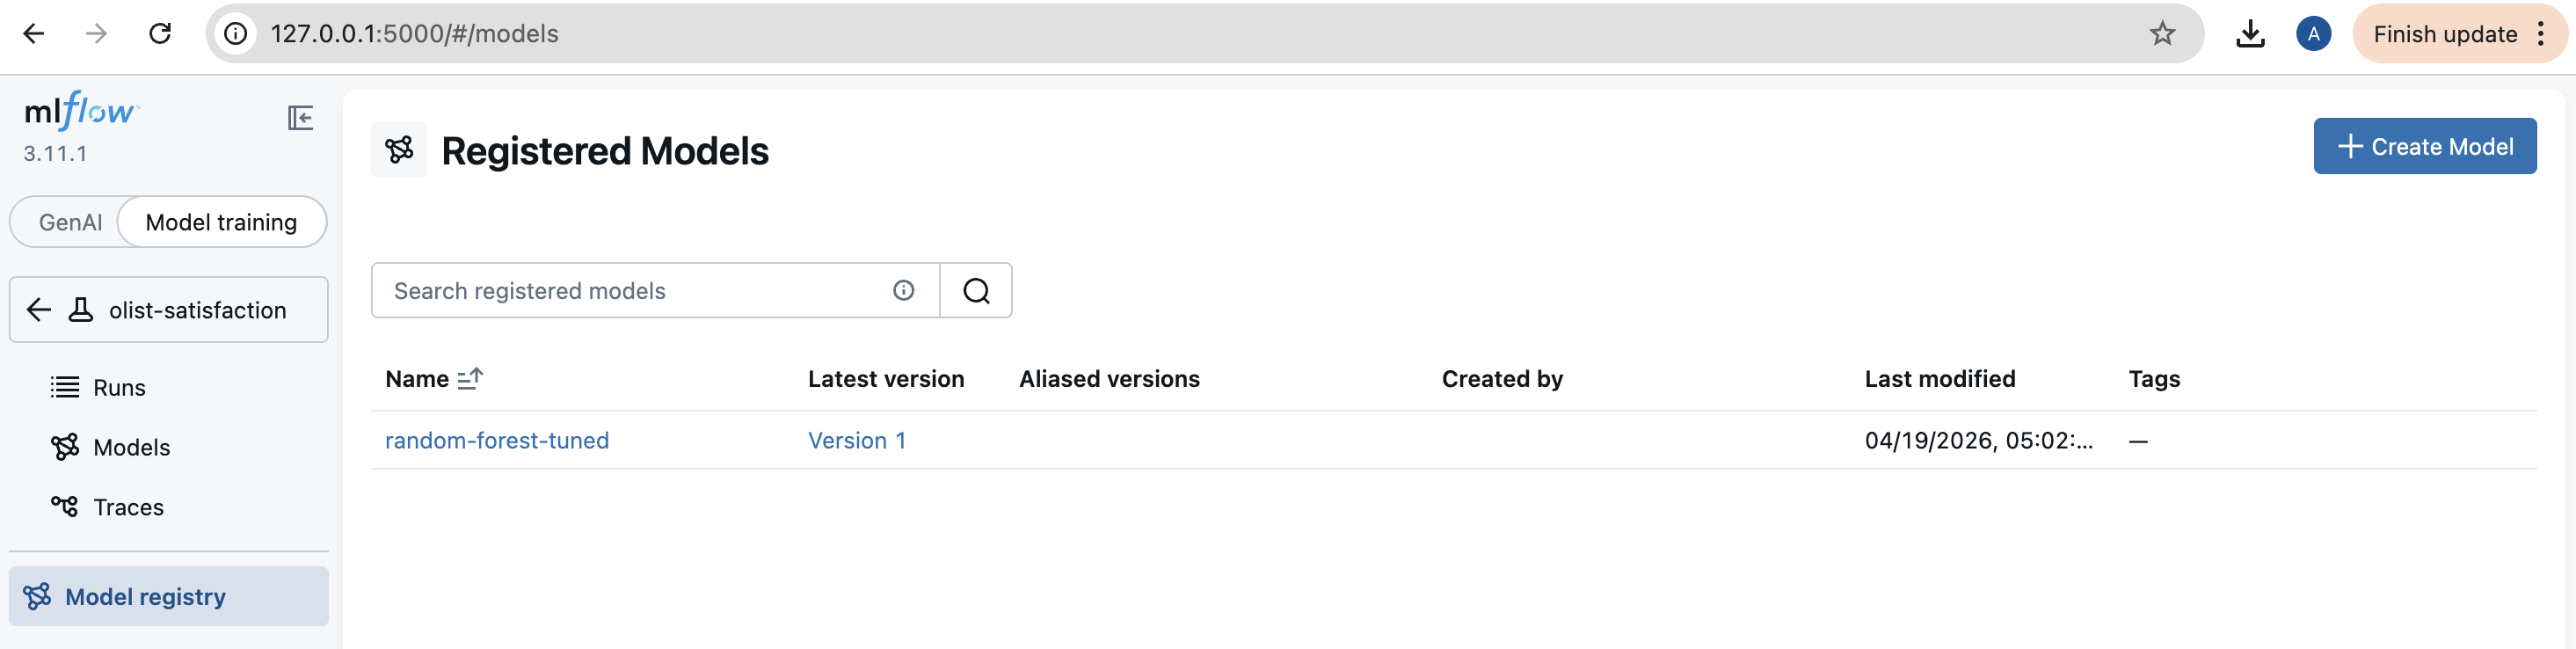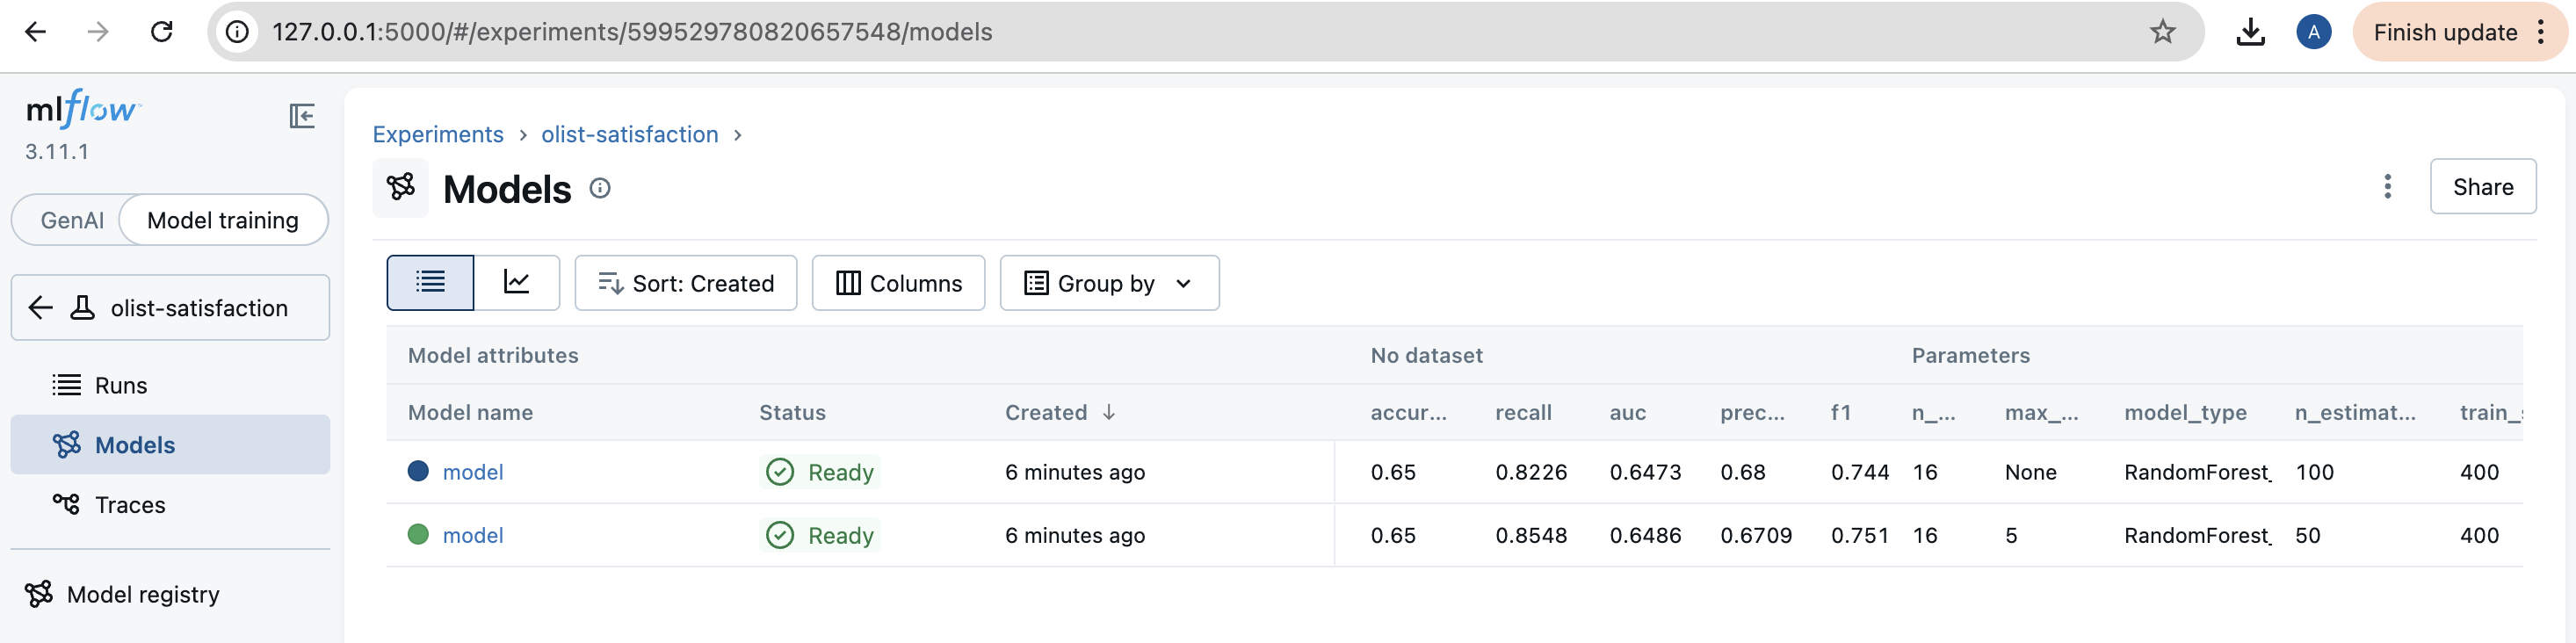

In [ ]:
import matplotlib.pyplot as plt

# Query all runs from our experiment
client = MlflowClient()
experiment = client.get_experiment_by_name(experiment_name)
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.auc DESC"]
)

In [ ]:
# Register the best model in the Model Registry
model_name = "random-forest-tuned"

# Register from the best run
model_uri = f"runs:/{'b6aa778950a745fa8deed1b7b980f6f6'}/model"

try:
    # Create registered model (first time)
    registered_model = mlflow.register_model(model_uri, model_name)
    print(f"Registered model: {model_name}")
    print(f"Version: {registered_model.version}")
except Exception as e:
    print(f"Model may already be registered: {e}")
    # Get latest version
    versions = client.get_latest_versions(model_name)
    if versions:
        registered_model = versions[0]
        print(f"Using existing version: {registered_model.version}")

Registered model 'random-forest-tuned' already exists. Creating a new version of this model...
2026/04/19 17:02:43 WARNING mlflow.tracking._model_registry.fluent: Run with id b6aa778950a745fa8deed1b7b980f6f6 has no artifacts at artifact path 'model', registering model based on models:/m-7b62314e84ce47d5b7f5e6620f3f8450 instead


Registered model: random-forest-tuned
Version: 1


Created version '1' of model 'random-forest-tuned'.


In [ ]:
# Transition the best model to Staging, then Production
version_1 = "1"

# Move to Staging first
client.transition_model_version_stage(
    name=model_name,
    version=version_1,
    stage="Staging"
)
print(f"Version {version_1} → Staging")

# After "validation" (in production, this would be automated tests)
print("\nSimulating validation checks...")
print("  ✓ AUC above threshold (0.80)")
print("  ✓ No NaN predictions")
print("  ✓ Predictions in [0, 1]")
print("  ✓ Latency acceptable")
print("All checks passed!\n")

# Promote to Production
client.transition_model_version_stage(
    name=model_name,
    version=version_1,
    stage="Production"
)
print(f"Version {version_1} → Production")

# Show current state
versions = client.search_model_versions(f"name='{model_name}'")
print(f"\nCurrent model registry state:")
for v in versions:
    print(f"  Version {v.version}: stage={v.current_stage}")

Version 1 → Staging

Simulating validation checks...
  ✓ AUC above threshold (0.80)
  ✓ No NaN predictions
  ✓ Predictions in [0, 1]
  ✓ Latency acceptable
All checks passed!

Version 1 → Production

Current model registry state:
  Version 1: stage=Production


/var/folders/gs/z8qql2l148g9gsv1fxp6tgwc0000gn/T/ipykernel_31930/3661119569.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
/var/folders/gs/z8qql2l148g9gsv1fxp6tgwc0000gn/T/ipykernel_31930/3661119569.py:21: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


# **Part 3: Model Serving API**

## 3A. Flask API Implementation

In [ ]:
# Create a clean project directory
import os
PROJECT_DIR = os.path.expanduser("~/hw4-mlops")
MODEL_DIR = os.path.join(PROJECT_DIR, "model")

os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")
print(f"Model directory: {MODEL_DIR}")

Project directory: /Users/argareeva/hw4-mlops
Model directory: /Users/argareeva/hw4-mlops/model


In [ ]:
import joblib
import numpy as np

model_path = os.path.join(MODEL_DIR, "model.pkl")
joblib.dump(pipeline, model_path)

# Verify it works by loading in a "fresh" context
loaded_model = joblib.load(model_path)
test_preds = loaded_model.predict(X_test[:5])
original_preds = pipeline.predict(X_test[:5])

print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.0f} KB")
print(f"\nVerification — predictions match: {np.array_equal(test_preds, original_preds)}")
print(f"Loaded predictions: {test_preds}")
print(f"Original predictions: {original_preds}")

Model saved to: /Users/argareeva/hw4-mlops/model/model.pkl
File size: 1175 KB

Verification — predictions match: True
Loaded predictions: [1 1 1 1 1]
Original predictions: [1 1 1 1 1]


In [ ]:
import json

# Save the feature schema — important for input validation in the API
feature_schema = {
    "numeric_features": numeric_cols,
    "categorical_features": cat_cols,
    "all_features": numeric_cols + cat_cols,
    "n_features": len(numeric_cols) + len(cat_cols),
}

# Also save a sample input for testing
sample_input = X_test.iloc[0].to_dict()
# Convert numpy types to Python types for JSON serialization
sample_input = {k: int(v) if isinstance(v, (np.integer,)) else
                   float(v) if isinstance(v, (np.floating,)) else
                   str(v) for k, v in sample_input.items()}

schema_path = os.path.join(MODEL_DIR, "schema.json")
with open(schema_path, 'w') as f:
    json.dump(feature_schema, f, indent=2)

sample_path = os.path.join(MODEL_DIR, "sample_input.json")
with open(sample_path, 'w') as f:
    json.dump(sample_input, f, indent=2)

print("Feature schema saved to:", schema_path)
print("Sample input saved to:", sample_path)
print(f"\nSample input:\n{json.dumps(sample_input, indent=2)}")

Feature schema saved to: /Users/argareeva/hw4-mlops/model/schema.json
Sample input saved to: /Users/argareeva/hw4-mlops/model/sample_input.json

Sample input:
{
  "customer_zip_code_prefix": "48120",
  "customer_city": "pojuca",
  "freight_value": "29.54",
  "product_name_lenght": "44.0",
  "product_description_lenght": "487.0",
  "product_photos_qty": "1.0",
  "product_weight_g": "2800.0",
  "product_category_name_english": "bed_bath_table",
  "seller_zip_code_prefix": "14940.0",
  "seller_city": "ibitinga",
  "seller_state": "SP",
  "payment_type": "credit_card",
  "delivery_days": "8.0",
  "delivery_vs_estimated": "-23.0",
  "is_repeat_customer": "1",
  "seller_state_match": "0",
  "product_volume": "8400.0",
  "total_order_items": "2.0",
  "log_price": "4.787491742782046",
  "seller_orders_count": "116.0",
  "is_delivered": "1"
}


In [ ]:
app_code = """import os
import json
import joblib
import pandas as pd
import numpy as np
from flask import Flask, request, jsonify

# ============================================================
# Initialize app and load model
# ============================================================
app = Flask(__name__)

MODEL_PATH  = os.environ.get('MODEL_PATH',  'model/model.pkl')
SCHEMA_PATH = os.environ.get('SCHEMA_PATH', 'model/schema.json')

print(f"Loading model from {MODEL_PATH}...")
model = joblib.load(MODEL_PATH)
print(f"Model loaded: {type(model).__name__}")

with open(SCHEMA_PATH) as f:
    schema = json.load(f)

REQUIRED_FEATURES     = schema['all_features']
NUMERIC_FEATURES      = schema['numeric_features']
CATEGORICAL_FEATURES  = schema['categorical_features']

# ── Validation rule sets ───────────────────────────────────────────────────
# Must be strictly > 0
POSITIVE_ONLY_FIELDS = {
    "product_weight_g",
    "product_volume",
    "total_order_items",
    "seller_orders_count",
}

# Must be >= 0
NON_NEGATIVE_FIELDS = {
    "freight_value",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix",
    "log_price",
}

# Must be 0 or 1
BINARY_FIELDS = {
    "is_repeat_customer",
    "seller_state_match",
    "is_delivered",
}

# Can be any value — including negative (early delivery = negative delta)
# delivery_vs_estimated  →  no range constraint needed


# ============================================================
# Helper: Input Validation
# ============================================================
def validate_input(data):
    \"\"\"Validate a single prediction input. Returns (is_valid, error_dict).\"\"\"
    errors = {}

    # 1. Missing fields
    missing = [f for f in REQUIRED_FEATURES if f not in data]
    if missing:
        errors['missing_fields'] = missing

    # 2. Numeric fields must be castable to float
    for field in NUMERIC_FEATURES:
        if field in data:
            try:
                float(data[field])
            except (ValueError, TypeError):
                errors[field] = f'expected numeric, got {type(data[field]).__name__}'

    # 3. Range checks (only if field passed the numeric check above)
    for field in POSITIVE_ONLY_FIELDS:
        if field in data and field not in errors:
            if float(data[field]) <= 0:
                errors[field] = 'must be a positive number (> 0)'

    for field in NON_NEGATIVE_FIELDS:
        if field in data and field not in errors:
            if float(data[field]) < 0:
                errors[field] = 'must be a non-negative number (>= 0)'

    for field in BINARY_FIELDS:
        if field in data and field not in errors:
            if int(float(data[field])) not in (0, 1):
                errors[field] = 'must be 0 or 1'

    # 4. Categorical fields must be strings
    for field in CATEGORICAL_FEATURES:
        if field in data:
            if not isinstance(data[field], str):
                errors[field] = f'expected string category, got {type(data[field]).__name__}'

    return len(errors) == 0, errors


# ============================================================
# Endpoints
# ============================================================

@app.route('/health', methods=['GET'])
def health():
    \"\"\"Health check — is the API alive and model loaded?\"\"\"
    if model is None:
        return jsonify({'status': 'error', 'message': 'model not loaded'}), 503
    return jsonify({'status': 'healthy', 'model': 'loaded'}), 200


@app.route('/predict', methods=['POST'])
def predict():
    \"\"\"Single prediction endpoint.\"\"\"
    data = request.get_json(silent=True)
    if not isinstance(data, dict):
        return jsonify({'error': 'Expected a JSON object'}), 400
    if not data:
        return jsonify({'error': 'No JSON body provided'}), 400

    is_valid, errors = validate_input(data)
    if not is_valid:
        return jsonify({'error': 'Invalid input', 'details': errors}), 400

    try:
        df   = pd.DataFrame([data])[REQUIRED_FEATURES]
        pred  = model.predict(df)[0]
        proba = model.predict_proba(df)[0][1]

        return jsonify({
            'prediction':  int(pred),
            'probability': round(float(proba), 4),
            'label':       'positive' if pred == 1 else 'negative'
        }), 200
    except Exception as e:
        return jsonify({'error': 'Prediction failed', 'message': str(e)}), 500


@app.route('/predict/batch', methods=['POST'])
def predict_batch():
    \"\"\"Batch prediction endpoint. Accepts a JSON array.\"\"\"
    data = request.get_json(silent=True)
    if not isinstance(data, list):
        return jsonify({'error': 'Expected a JSON array'}), 400
    if len(data) == 0:
        return jsonify({'error': 'Empty array'}), 400
    if len(data) > 100:
        return jsonify({'error': f'Max 100 records per batch, got {len(data)}'}), 400

    all_errors = {}
    for i, record in enumerate(data):
        is_valid, errors = validate_input(record)
        if not is_valid:
            all_errors[f'record_{i}'] = errors

    if all_errors:
        return jsonify({'error': 'Invalid inputs', 'details': all_errors}), 400

    try:
        df     = pd.DataFrame(data)[REQUIRED_FEATURES]
        preds  = model.predict(df)
        probas = model.predict_proba(df)[:, 1]

        results = [{
            'prediction':  int(p),
            'probability': round(float(pr), 4),
            'label':       'positive' if p == 1 else 'negative'
        } for p, pr in zip(preds, probas)]

        return jsonify({'predictions': results, 'count': len(results)}), 200
    except Exception as e:
        return jsonify({'error': 'Batch prediction failed', 'message': str(e)}), 500


# ============================================================
# Run
# ============================================================
if __name__ == '__main__':
    port = int(os.environ.get('PORT', 5001))
    app.run(host='0.0.0.0', port=port, debug=True)
""".strip()

app_path = os.path.join(PROJECT_DIR, "app.py")
with open(app_path, 'w') as f:
    f.write(app_code)

print(f"app.py written to: {app_path}")
print(f"Lines: {len(app_code.splitlines())}")
print("\n--- app.py preview (first 30 lines) ---")
for i, line in enumerate(app_code.splitlines()[:30], 1):
    print(f"  {i:3d}  {line}")
print("  ...")

app.py written to: /Users/argareeva/hw4-mlops/app.py
Lines: 183

--- app.py preview (first 30 lines) ---
    1  import os
    2  import json
    3  import joblib
    4  import pandas as pd
    5  import numpy as np
    6  from flask import Flask, request, jsonify
    7  
    8  # ============================================================
    9  # Initialize app and load model
   10  # ============================================================
   11  app = Flask(__name__)
   12  
   13  MODEL_PATH  = os.environ.get('MODEL_PATH',  'model/model.pkl')
   14  SCHEMA_PATH = os.environ.get('SCHEMA_PATH', 'model/schema.json')
   15  
   16  print(f"Loading model from {MODEL_PATH}...")
   17  model = joblib.load(MODEL_PATH)
   18  print(f"Model loaded: {type(model).__name__}")
   19  
   20  with open(SCHEMA_PATH) as f:
   21      schema = json.load(f)
   22  
   23  REQUIRED_FEATURES     = schema['all_features']
   24  NUMERIC_FEATURES      = schema['numeric_features']
   25  CATEGORICAL_F

In [ ]:
# Start the Flask server in a subprocess
# We run it in the background so we can continue using the notebook
import subprocess
import time
import sys

flask_process = subprocess.Popen(
    [sys.executable, 'app.py'],
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    env={**os.environ, 'PORT': '5050'}
)

# Give it a moment to start
time.sleep(3)

if flask_process.poll() is None:
    print("Flask server is running! (PID: {})".format(flask_process.pid))
    print("API available at: http://localhost:5050")
else:
    # Server failed to start — show the error
    stderr = flask_process.stderr.read().decode()
    print(f"ERROR: Flask server failed to start:\n{stderr}")

Flask server is running! (PID: 33327)
API available at: http://localhost:5050


## 3B. Local Testing

In [ ]:
X_test.to_csv(os.path.join(MODEL_DIR, "X_test.csv"), index=False)
print(f"X_test saved: {os.path.join(MODEL_DIR, 'X_test.csv')}")

X_test saved: /Users/argareeva/hw4-mlops/model/X_test.csv


In [ ]:
test_api = """import json
import os
import requests
import numpy as np
import pandas as pd

PROJECT_DIR = os.path.expanduser("~/hw4-mlops")
MODEL_DIR = os.path.join(PROJECT_DIR, "model")

with open(os.path.join(MODEL_DIR, "sample_input.json")) as f:
    sample = json.load(f)

X_test = pd.read_csv(os.path.join(MODEL_DIR, "X_test.csv"))

def print_header(title):
    print("=" * 60)
    print(title)
    print("=" * 60)


# TEST 1: Health
def test_health():
    print_header("TEST 1: Health Check (GET /health)")

    response = requests.get("http://localhost:5050/health")
    print(f"Status Code: {response.status_code}")

    data = response.json()
    print(json.dumps(data, indent=2))

    assert response.status_code == 200
    assert "status" in data
    assert "model" in data

    print("PASS")


# TEST 2: Single prediction
def test_single_prediction():
    print_header("TEST 2: Single Prediction (POST /predict)")

    print("Sending sample input...")
    response = requests.post("http://localhost:5050/predict", json=sample)

    print(f"Status Code: {response.status_code}")
    data = response.json()
    print(json.dumps(data, indent=2))

    assert response.status_code == 200
    assert "prediction" in data
    assert "probability" in data
    assert "label" in data
    assert data["label"] in ("positive", "negative")

    print("PASS")


# TEST 3: Batch prediction
def test_batch_prediction():
    print_header("TEST 3: Batch Prediction (POST /predict/batch)")

    batch_data = []
    for i in range(5):
        row = X_test.iloc[i].to_dict()
        row = {
            k: int(v) if isinstance(v, (np.integer,))
            else float(v) if isinstance(v, (np.floating,))
            else str(v)
            for k, v in row.items()
        }
        batch_data.append(row)

    print(f"Sending batch of {len(batch_data)} records...")
    response = requests.post("http://localhost:5050/predict/batch", json=batch_data)

    print(f"Status Code: {response.status_code}")
    data = response.json()
    print(json.dumps(data, indent=2))

    assert response.status_code == 200
    assert "predictions" in data
    assert "count" in data
    assert data["count"] == 5
    assert len(data["predictions"]) == 5
    # Check labels are correct values
    for pred in data["predictions"]:
        assert pred["label"] in ("positive", "negative")

    print("PASS")


# TEST 4: Missing field
def test_missing_field():
    print_header("TEST 4: Missing Required Field")

    bad_input = sample.copy()
    removed_key = list(bad_input.keys())[0]
    del bad_input[removed_key]

    print(f"Removed field: {removed_key}")
    response = requests.post("http://localhost:5050/predict", json=bad_input)

    print(f"Status Code: {response.status_code}")
    data = response.json()
    print(json.dumps(data, indent=2))

    assert response.status_code == 400
    assert "error" in data
    assert "details" in data

    print("PASS")


# TEST 5: Invalid numeric type
def test_invalid_type():
    print_header("TEST 5: Invalid Type (freight_value = string)")

    bad_input = sample.copy()
    # freight_value is a required numeric field — passing a string must trigger 400
    bad_input["freight_value"] = "not_a_number"

    print("Corrupted field: freight_value")
    response = requests.post("http://localhost:5050/predict", json=bad_input)

    print(f"Status Code: {response.status_code}")
    data = response.json()
    print(json.dumps(data, indent=2))

    assert response.status_code == 400
    assert "error" in data
    assert "details" in data

    print("PASS")


if __name__ == "__main__":
    try:
        test_health()
        test_single_prediction()
        test_batch_prediction()
        test_missing_field()
        test_invalid_type()

        print("=" * 60)
        print("ALL 5 TESTS PASSED")
        print("=" * 60)

    except AssertionError as e:
        print(f"TEST FAILED: {e}")
""".strip()

test_path = os.path.join(PROJECT_DIR, "test_api.py")
with open(test_path, 'w') as f:
    f.write(test_api)

print(f"test_api.py written to: {test_path}")
print(f"Lines: {len(test_api.splitlines())}")
print("\n--- test_api.py preview (first 30 lines) ---")
for i, line in enumerate(test_api.splitlines()[:30], 1):
    print(f"  {i:3d}  {line}")
print("  ...")

test_api.py written to: /Users/argareeva/hw4-mlops/test_api.py
Lines: 149

--- test_api.py preview (first 30 lines) ---
    1  import json
    2  import os
    3  import requests
    4  import numpy as np
    5  import pandas as pd
    6  
    7  PROJECT_DIR = os.path.expanduser("~/hw4-mlops")
    8  MODEL_DIR = os.path.join(PROJECT_DIR, "model")
    9  
   10  with open(os.path.join(MODEL_DIR, "sample_input.json")) as f:
   11      sample = json.load(f)
   12  
   13  X_test = pd.read_csv(os.path.join(MODEL_DIR, "X_test.csv"))
   14  
   15  def print_header(title):
   16      print("=" * 60)
   17      print(title)
   18      print("=" * 60)
   19  
   20  
   21  # TEST 1: Health
   22  def test_health():
   23      print_header("TEST 1: Health Check (GET /health)")
   24  
   25      response = requests.get("http://localhost:5050/health")
   26      print(f"Status Code: {response.status_code}")
   27  
   28      data = response.json()
   29      print(json.dumps(data, indent=2))
 

### All tests passed locally

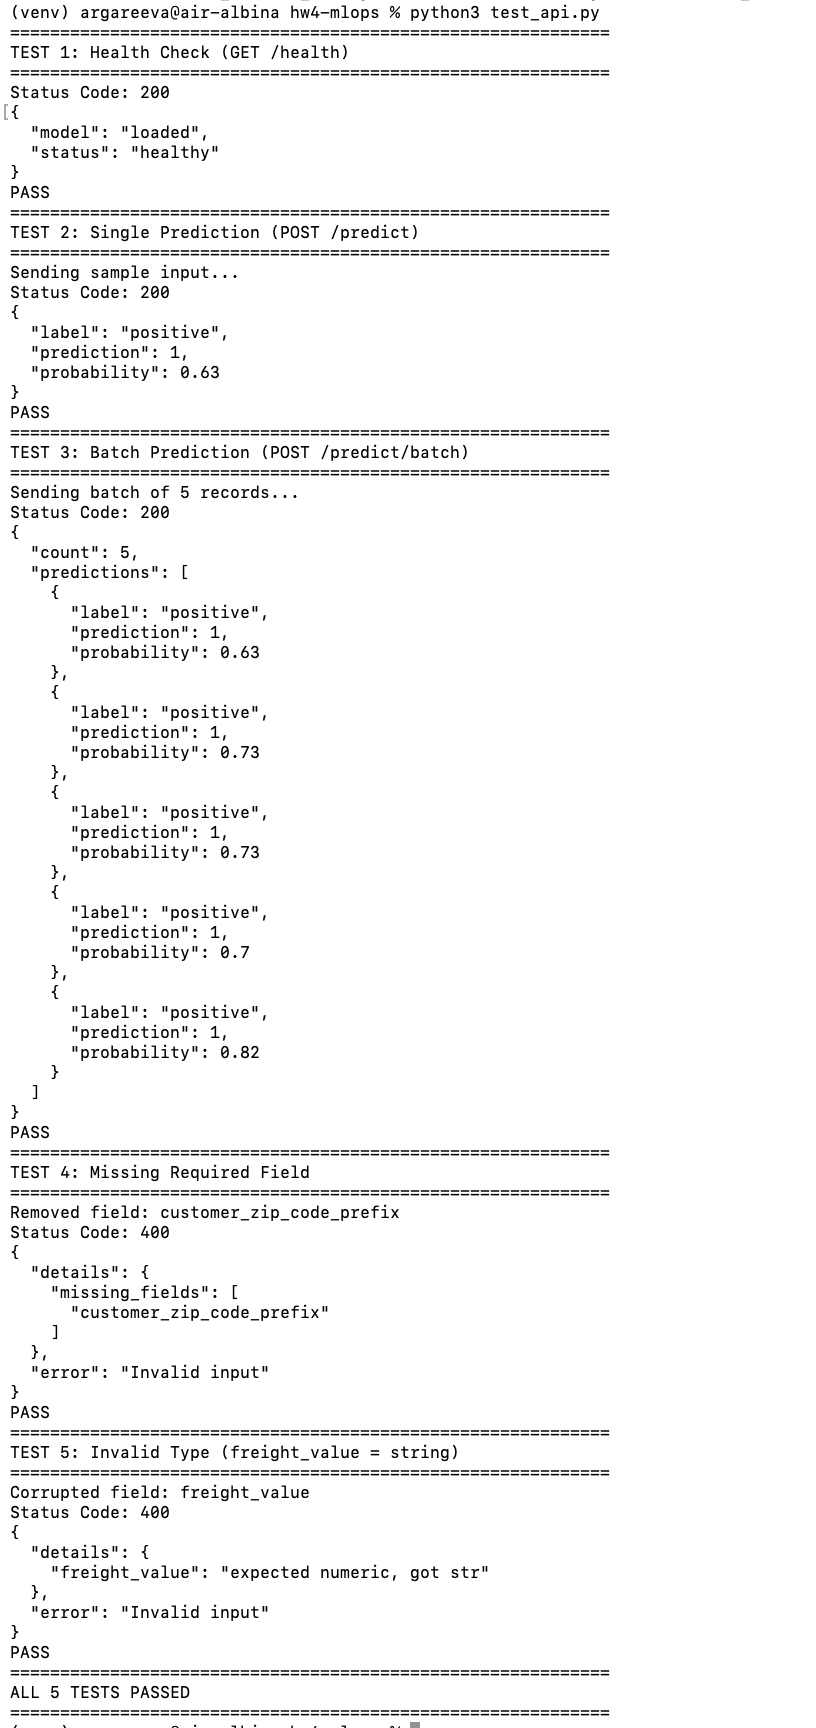

# Part 4: Containerization & Cloud Deployment

## 4A. Docker Containerization

In [ ]:
# Check that Docker is installed and running
import shutil

docker_path = shutil.which('docker')
if docker_path is None:
    print("ERROR: Docker is not installed (or not on your PATH).")
    print()
    print("To install Docker Desktop:")
    print("  1. Go to https://docs.docker.com/desktop/setup/install/mac-install/")
    print("  2. Download and install Docker Desktop for Mac")
    print("  3. Launch Docker Desktop and wait for it to say 'running'")
    print("  4. Re-run this cell")
else:
    # Docker binary exists — check if the daemon is actually running
    check = subprocess.run(['docker', 'info'], capture_output=True, text=True, timeout=10)
    if check.returncode == 0:
        # Extract server version from output
        for line in check.stdout.splitlines():
            if 'Server Version' in line:
                print(f"Docker is ready! ({line.strip()})")
                break
        else:
            print("Docker is ready!")
    else:
        print("ERROR: Docker is installed but the daemon is not running.")
        print()
        print("Open Docker Desktop and wait for the whale icon to stop animating.")
        print("Then re-run this cell.")

Docker is ready! (Server Version: 29.4.0)


In [ ]:
# Generate requirements.txt
requirements = """flask==3.0.0
gunicorn==21.2.0
joblib==1.3.2
scikit-learn==1.4.2
pandas==2.1.4
numpy==1.26.2
requests==2.31.0
""".strip()

req_path = os.path.join(PROJECT_DIR, "requirements.txt")
with open(req_path, 'w') as f:
    f.write(requirements)

print("requirements.txt:")
print(requirements)
print(f"\nSaved to: {req_path}")

requirements.txt:
flask==3.0.0
gunicorn==21.2.0
joblib==1.3.2
scikit-learn==1.4.2
pandas==2.1.4
numpy==1.26.2
requests==2.31.0

Saved to: /Users/argareeva/hw4-mlops/requirements.txt


In [ ]:
# Generate Dockerfile
dockerfile = """FROM python:3.10-slim

WORKDIR /app

# Copy requirements first (for Docker layer caching)
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the application
COPY . .

# Expose the port
EXPOSE 5000

# Run with gunicorn (production server)
CMD ["gunicorn", "--bind", "0.0.0.0:5050", "--workers", "2", "--timeout", "120", "app:app"]
""".strip()

dockerfile_path = os.path.join(PROJECT_DIR, "Dockerfile")
with open(dockerfile_path, 'w') as f:
    f.write(dockerfile)

print("Dockerfile:")
print(dockerfile)
print(f"\nSaved to: {dockerfile_path}")

Dockerfile:
FROM python:3.10-slim

WORKDIR /app

# Copy requirements first (for Docker layer caching)
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the application
COPY . .

# Expose the port
EXPOSE 5000

# Run with gunicorn (production server)
CMD ["gunicorn", "--bind", "0.0.0.0:5050", "--workers", "2", "--timeout", "120", "app:app"]

Saved to: /Users/argareeva/hw4-mlops/Dockerfile


In [ ]:
# Generate .dockerignore
dockerignore = """__pycache__/
*.pyc
.git/
.env
*.ipynb
*.csv
venv/
.DS_Store
""".strip()

ignore_path = os.path.join(PROJECT_DIR, ".dockerignore")
with open(ignore_path, 'w') as f:
    f.write(dockerignore)

print(".dockerignore:")
print(dockerignore)
print(f"\nSaved to: {ignore_path}")

.dockerignore:
__pycache__/
*.pyc
.git/
.env
*.ipynb
*.csv
venv/
.DS_Store

Saved to: /Users/argareeva/hw4-mlops/.dockerignore


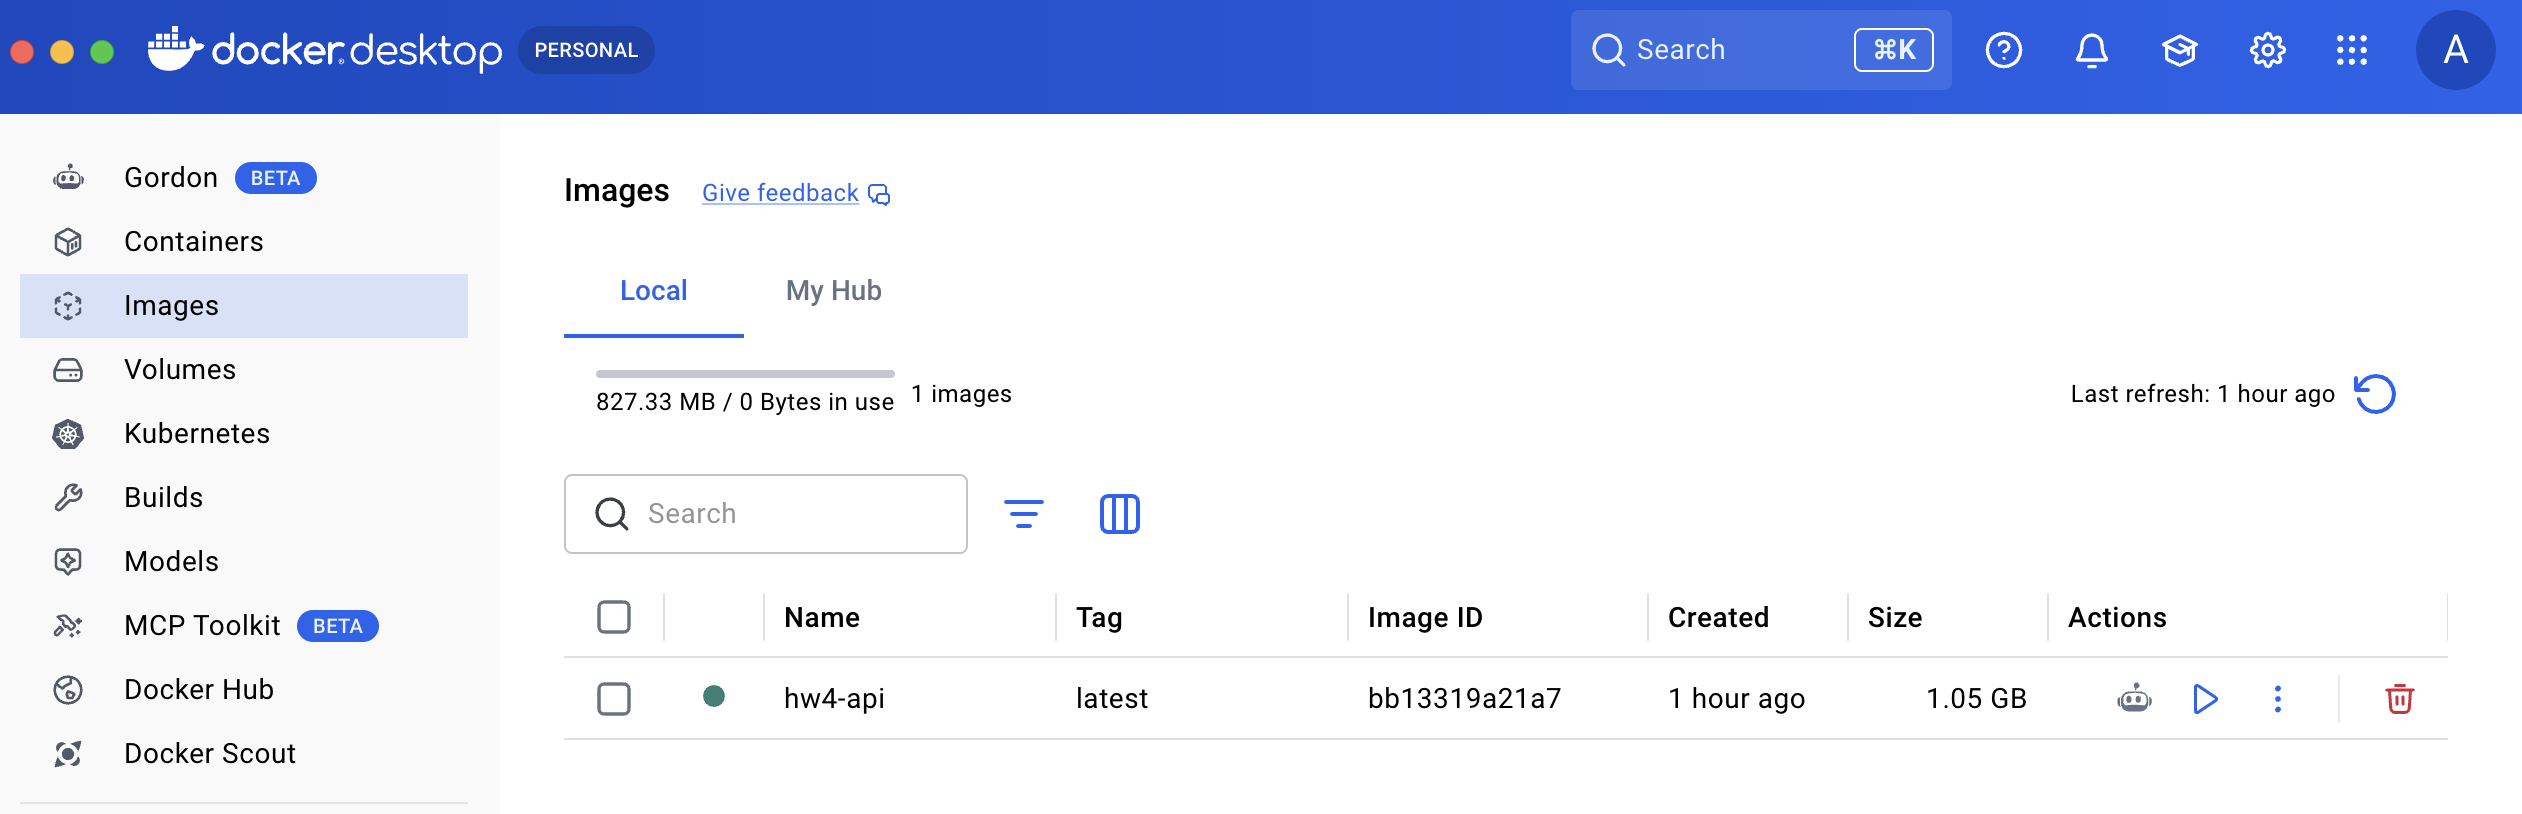

## 4B. Cloud Deployment

### Option A: Render.com
+ Created a free account at render.com.
+ Pushed hw4-mlops project to a public [GitHub repository](https://github.com/argareeva/hw4-mlops).
+ On Render, created a new Web Service and connected it to my GitHub repo.

https://hw4-mlops-5csb.onrender.com/

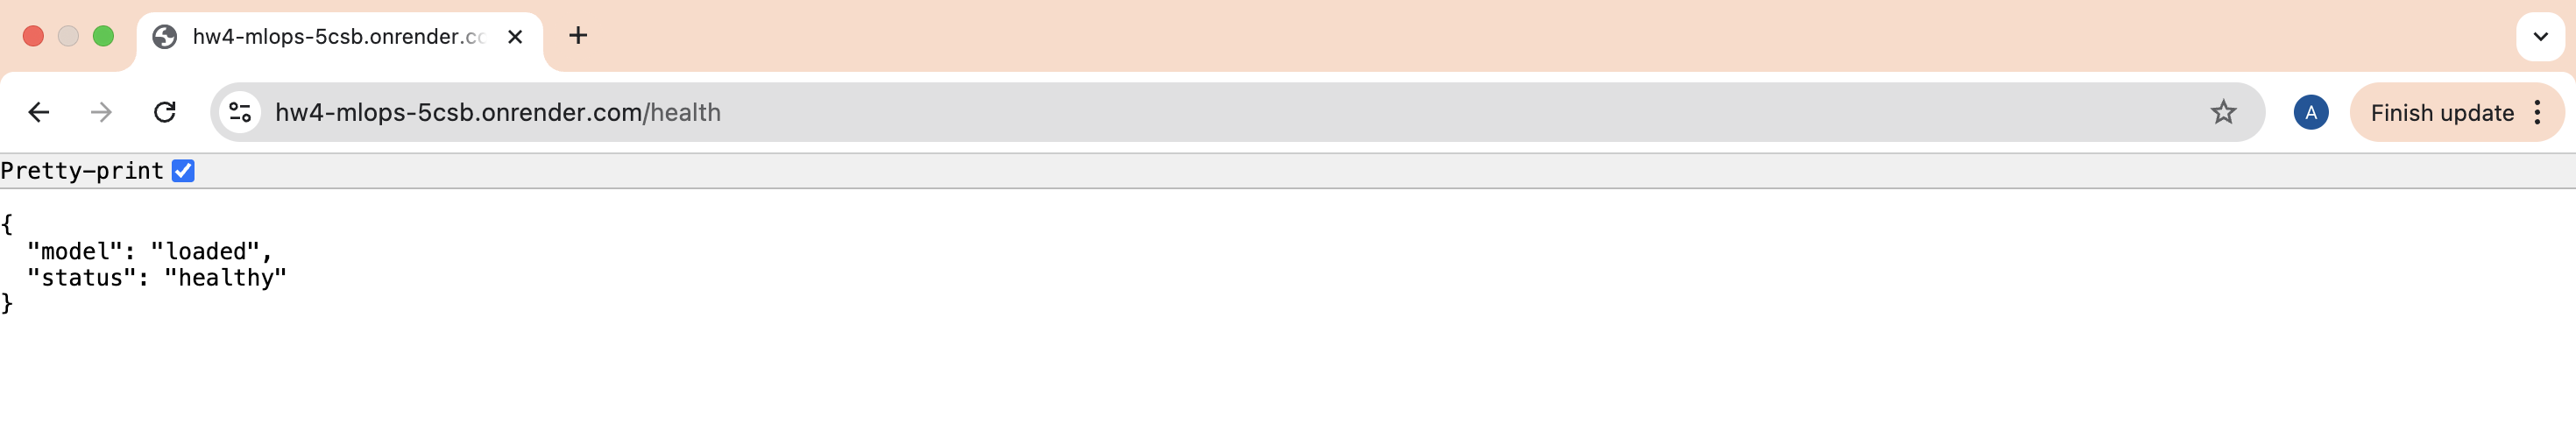

### All tests passed dev environment

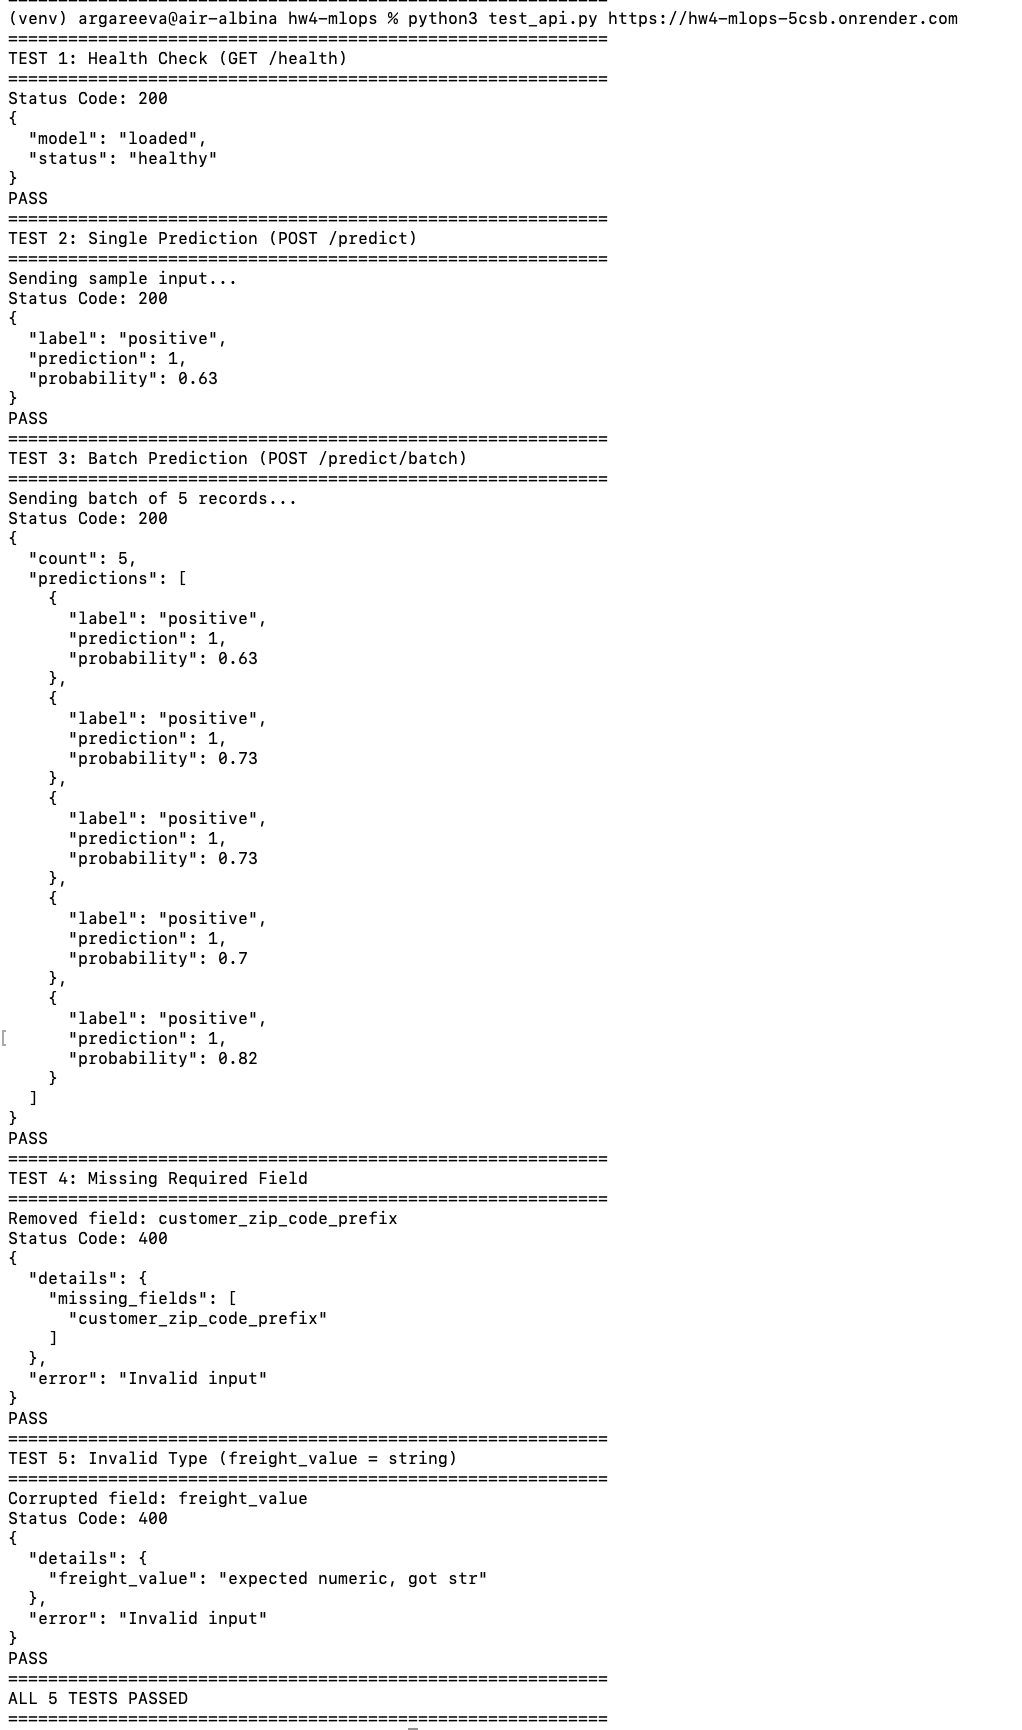